# Stack Overflow Developer Survey Analysis (2020–2024)

## 1. Introduction

### Metrics Used in This Study
- Usage: Percentage of respondents who reported using a language
- Loved: Percentage of developers who want to continue using a language
- Desired: Percentage of developers who want to learn or adopt a language
- Admired: Combined indicator of satisfaction and future interest

## 2. Data Sources

In [111]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
YEARS = range(2020, 2025)

data_frames: dict = {}

for year in YEARS:
    path = f"../data/survey_{year}.csv"
    data_frames[year] = pd.read_csv(path)

In [63]:
# Testing purposes only

for year, df in data_frames.items():
    print(year, df.shape)

2020 (64461, 61)
2021 (83439, 48)
2022 (73268, 79)
2023 (89184, 84)
2024 (65437, 114)


## 3. Data Cleaning and Preparation

## 4. Analysis of Usage Trends

In [89]:
def calculate_usage(df, column: str):
    """
    Calculate usage percentage for a multi-select language column.
    Matches Stack Overflow Developer Survey methodology.
    """
    # Removes missing responses
    responses = df[column].dropna()

    # Total number of respondents who answered the question
    total_respondents = responses.shape[0]

    # Count how many times each language appears
    language_counts = responses.str.split(";").explode().value_counts()

    # Convert to percentage
    usage_percentage = ((language_counts / total_respondents) * 100)

    return usage_percentage.sort_values(ascending=False)

In [104]:
usage_by_year: dict = {}

for year, data_frame in data_frames.items():
    usage_by_year[year] = calculate_usage(
        data_frame,
        "LanguageHaveWorkedWith"
    )

print(round(usage_by_year[2024], 2).head(20))

LanguageHaveWorkedWith
JavaScript                 62.75
HTML/CSS                   53.25
Python                     51.42
SQL                        51.35
TypeScript                 38.75
Bash/Shell (all shells)    34.17
Java                       30.53
C#                         27.31
C++                        23.14
C                          20.39
PHP                        18.33
PowerShell                 13.94
Go                         13.56
Rust                       12.65
Kotlin                      9.48
Lua                         6.24
Dart                        6.02
Assembly                    5.41
Ruby                        5.27
Swift                       4.74
Name: count, dtype: float64


In [106]:
usage_trends = pd.DataFrame(usage_by_year)

print(round(usage_trends, 2).sort_values(by=YEARS[-1], ascending=False).head(20))

                          2020   2021   2022   2023   2024
LanguageHaveWorkedWith                                    
JavaScript               67.66  65.07  65.44  63.93  62.75
HTML/CSS                 63.06  56.17  55.15  53.24  53.25
Python                   44.07  48.32  48.12  49.53  51.42
SQL                      54.75  47.15  49.49  48.91  51.35
TypeScript               25.41  30.25  34.87  39.06  38.75
Bash/Shell (all shells)  33.08  27.18  29.10  32.54  34.17
Java                     40.21  35.41  33.31  30.71  30.53
C#                       31.44  27.91  28.01  27.76  27.31
C++                      23.89  24.35  22.58  22.53  23.14
C                        21.76  21.04  19.29  19.44  20.39
PHP                      26.15  22.01  20.89  18.68  18.33
PowerShell                 NaN  10.77  12.08  13.66  13.94
Go                        8.78   9.57  11.16  13.30  13.56
Rust                      5.10   7.04   9.33  13.11  12.65
Kotlin                    7.79   8.34   9.17   9.11   9.

<Axes: title={'center': 'Rust Usage Trend (2020–2024)'}>

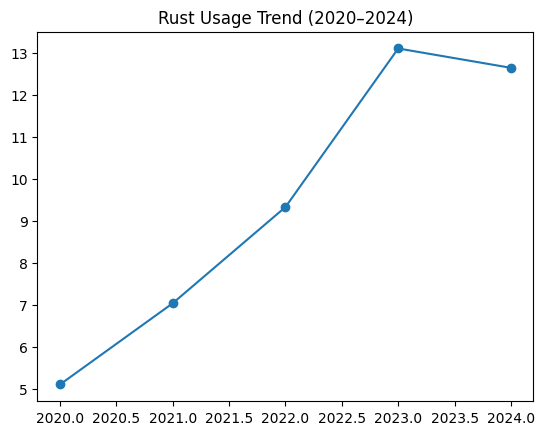

In [112]:
usage_trends.loc["Rust"].plot(
    marker="o",
    title="Rust Usage Trend (2020–2024)"
)


In [108]:
top_10_languages_by_usage = (
    usage_trends
    .sort_values(by=2024, ascending=False)
    .head(10)
)

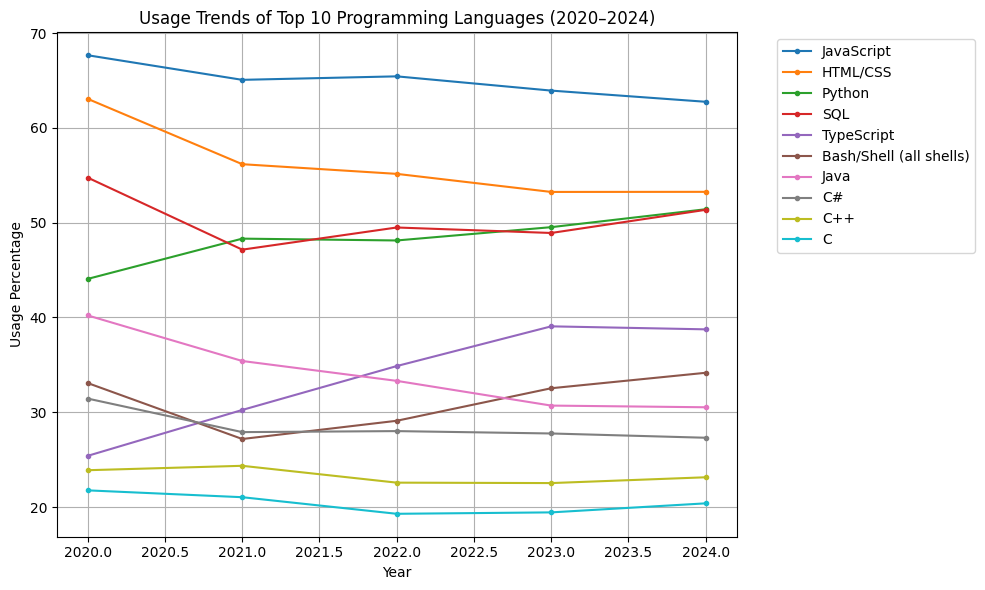

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for language in top_10_languages_by_usage.index:
    plt.plot(
        top_10_languages_by_usage.columns,
        top_10_languages_by_usage.loc[language],
        marker=".",
        label=language
    )

plt.xlabel("Year")
plt.ylabel("Usage Percentage")
plt.title("Usage Trends of Top 10 Programming Languages (2020–2024)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


## 5. Analysis of Loved and Desired Metrics

## 6. Comparative Trends Across Languages

## 7. Summary of Key Findings